# IR Vibrational Spectroscopy Widget

This notebook demonstrates the IR vibrational widget for Jupyter and Marimo.
Frequency data can come from a **Psi4 PsiAPI** wavefunction object, a cclib-parsed
output file, or plain NumPy arrays — the widget accepts all three.

Sections:
1. Water (H₂O) — simple array input
2. Hydronium ion (H₃O⁺) — full Psi4 calculation, molecular visualisation
3. Benzene (C₆H₆) — Psi4 frequencies, spectrum controls, and MO visualisation

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from ir_widget import IRWidget

## Example 1: Water Molecule (H₂O)

Water has 3 IR-active normal modes:
- Bending mode (~1595 cm⁻¹)
- Symmetric O–H stretch (~3657 cm⁻¹)
- Asymmetric O–H stretch (~3756 cm⁻¹)

Here we supply frequency and intensity arrays directly.

In [3]:
frequencies = np.array([1595.0, 3657.0, 3756.0])
intensities = np.array([75.0, 20.0, 45.0])

widget_h2o = IRWidget()
widget_h2o.load_data(frequencies, intensities, formula="H₂O")
widget_h2o

## Example 2: Hydronium Ion (H₃O⁺) — Psi4 Calculation

Using PsiAPI directly we run an HF/6-31G(d,p) geometry optimisation followed by a
harmonic frequency calculation, then load the wavefunction straight into the widget.
This gives us atom coordinates and normal-mode displacement vectors needed for
molecular visualisation — no output file or cclib parsing required.

H₃O⁺ has **6 normal modes** (3N − 6, with N = 4).

In [4]:
import psi4

for f in Path().glob('psi.*.clean'):
    f.unlink()

psi4.core.set_output_file('h3o_freq.dat', False)

In [5]:
h3o = psi4.geometry("""
  1 1
  O  0.0000  0.0000  0.0000
  H  0.9200 -0.5300  0.0000
  H -0.9200 -0.5200  0.0000
  H  0.0000  1.0600  0.0000
""")

psi4.set_options({'reference': 'rhf'})
psi4.optimize('hf/6-31g(d,p)', molecule=h3o)
energy, wfn = psi4.frequency('hf/6-31g(d,p)', molecule=h3o, return_wfn=True)
print(f'HF/6-31G(d,p) energy: {energy:.6f} Eh')

Some dependencies such as QCElemental have not yet finished migration to pydantic v2. If issues are encountered please downgrade pydantic or upgrade QCElemental as appropriate


Optimizer: Optimization complete!
HF/6-31G(d,p) energy: -76.308865 Eh


In [6]:
widget_h3o = IRWidget()
widget_h3o.load_from_psi4_wfn(wfn)
widget_h3o.broadening = 'lorentzian'
widget_h3o.fwhm = 20.0
widget_h3o

## Inspecting the Results

All vibrational data are available in `widget_h3o.data`, including Cartesian
displacement vectors (`displacements`) and equilibrium atom coordinates (`atoms`)
extracted directly from the wavefunction.

In [7]:
data = widget_h3o.data
print(f"Molecule : {data['formula']}")
print(f"Modes    : {data['n_modes']}")
if 'atoms' in data:
    print(f"Atoms    : {len(data['atoms'])}")
print()
print(f"{'Mode':>4}  {'Freq (cm⁻¹)':>13}  {'Intensity (km/mol)':>18}")
print("─" * 40)
for mode in data['modes']:
    print(f"{mode['mode']:>4}  {mode['frequency']:>13.2f}  {mode['intensity']:>18.4f}")

Molecule : H3O
Modes    : 6
Atoms    : 4

Mode    Freq (cm⁻¹)  Intensity (km/mol)
────────────────────────────────────────
   1        -577.75            764.6608
   2        1746.56            164.3331
   3        1746.63            164.3560
   4        3872.18              0.0019
   5        4043.59            733.7366
   6        4044.00            733.6801


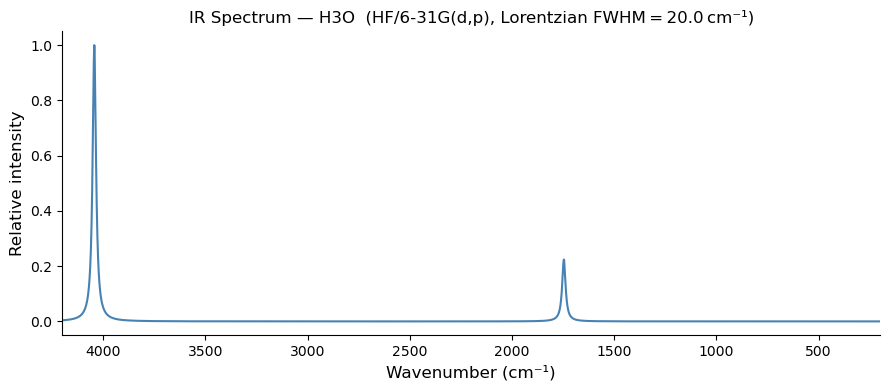

In [8]:
# Static Lorentzian-broadened IR spectrum via matplotlib.
# Useful for publication figures and saving to disk.
freqs  = [m['frequency']  for m in data['modes']]
intens = [m['intensity']  for m in data['modes']]

x_range = np.linspace(200, 4200, 5000)
fwhm_plot = 20.0
gamma = fwhm_plot / 2

spectrum = np.zeros_like(x_range)
for f, i in zip(freqs, intens):
    spectrum += i * gamma**2 / ((x_range - f)**2 + gamma**2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_range, spectrum / spectrum.max(), color='steelblue', linewidth=1.5)

# Conventional IR plot: high wavenumber on the left
ax.invert_xaxis()
ax.set_xlim(4200, 200)
ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=12)
ax.set_ylabel('Relative intensity', fontsize=12)
ax.set_title(
    f"IR Spectrum — {data['formula']}  "
    f"(HF/6-31G(d,p), Lorentzian FWHM = {fwhm_plot} cm⁻¹)",
    fontsize=12,
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Molecular Visualization

The `MolVisualizerWidget` uses [py3Dmol](https://github.com/3dmol/3Dmol.js/tree/master/py3Dmol)
(backed by 3Dmol.js) to display an interactive ball-and-stick model and animate
vibrational modes — no Jupyter extension needed.

> **Note:** Atom coordinates and displacement vectors are only available when data
> was loaded from a Psi4 wavefunction (`load_from_psi4_wfn`) or a cclib-parsed file.

In [9]:
from ir_widget import MolVisualizerWidget

vis = MolVisualizerWidget(widget_h3o.data)
print(f"H3O⁺: {len(vis.data['atoms'])} atoms, {len(vis.data['modes'])} vibrational modes")

H3O⁺: 4 atoms, 6 vibrational modes


In [10]:
# Static ball-and-stick structure
vis.view_structure()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
# Animated vibrational modes — select from dropdown
vis.view_mode_selector(amplitude=0.6)

In [12]:
# Linked panel: spectrum + animated molecule inset
# Select a mode from the dropdown to animate it and highlight its spectral peak.
vis.view_linked(amplitude=0.6, fwhm=20.0)

## Example 3: Benzene (C₆H₆) — Psi4 Frequency Calculation

A more complex molecule with 30 vibrational modes (3N − 6, N = 12).
We also compute molecular orbitals via `psi4.cubeprop()` for HOMO/LUMO
visualisation.

In [17]:
psi4.core.set_output_file('benzene_freq.dat', False)

benzene = psi4.geometry(
    "pubchem:benzene"
# """
#   0 1
#   C  0.0000  1.3970  0.0000
#   C  1.2095  0.6985  0.0000
#   C  1.2095 -0.6985  0.0000
#   C  0.0000 -1.3970  0.0000
#   C -1.2095 -0.6985  0.0000
#   C -1.2095  0.6985  0.0000
#   H  0.0000  2.4840  0.0000
#   H  2.1510  1.2420  0.0000
#   H  2.1510 -1.2420  0.0000
#   H  0.0000 -2.4840  0.0000
#   H -2.1510 -1.2420  0.0000
#   H -2.1510  1.2420  0.0000
#   symmetry c1
#   units angstrom
# """
)

psi4.set_options({'reference': 'rhf', 'basis': '6-31g*', 'scf_type': 'df'})
psi4.set_memory('4 GB')

energy_benz, wfn_benz = psi4.frequency('hf/6-31g*', molecule=benzene, return_wfn=True)
print(f'HF/6-31G* energy: {energy_benz:.6f} Eh')

	Searching PubChem database for benzene (single best match returned)
	Found 1 result(s)
HF/6-31G* energy: -230.701866 Eh


In [19]:
widget_benz = IRWidget()
widget_benz.load_from_psi4_wfn(wfn_benz)
widget_benz.broadening = 'lorentzian'
widget_benz.fwhm = 15.0
widget_benz

### Spectrum Display Options

Broadening type, peak width (FWHM), and wavenumber range can all be adjusted
programmatically after the widget is created.

In [20]:
# Gaussian broadening with wider FWHM
widget_benz.broadening = "gaussian"
widget_benz.fwhm = 25.0
widget_benz

In [21]:
# Back to Lorentzian with narrower peaks
widget_benz.broadening = "lorentzian"
widget_benz.fwhm = 10.0
widget_benz.x_min = 400
widget_benz.x_max = 3500
widget_benz

### Molecular Orbital Visualization

`psi4.cubeprop()` writes volumetric cube files for the requested orbitals.
For benzene (42 electrons, 21 alpha), the HOMO is orbital 21 (`wfn.nalpha()`).
Positive lobe is shown in blue, negative lobe in red.

In [22]:
# Benzene: 42 electrons → 21 alpha → HOMO is orbital 21
homo_num = wfn_benz.nalpha()   # = 21 for benzene
orb_list = list(range(homo_num - 2, homo_num + 3))  # HOMO-2 through LUMO+1

psi4.set_options({
    'cubeprop_tasks': ['orbitals'],
    'cubeprop_orbitals': orb_list,
    'cubic_grid_spacing': [0.2, 0.2, 0.2],
})
psi4.cubeprop(wfn_benz)
print(f"Generated cube files for orbitals: {orb_list}")
print(f"HOMO is orbital {homo_num}")

Generated cube files for orbitals: [19, 20, 21, 22, 23]
HOMO is orbital 21


In [23]:
from ir_widget import MolVisualizerWidget

vis_benz = MolVisualizerWidget(widget_benz.data)

# Build cube filenames. Psi4 zero-pads the index to len(str(max(orb_list))) digits.
ndigits = len(str(max(orb_list)))
cube_files = [f'Psi_a_{n:0{ndigits}d}_{n}-A.cube' for n in orb_list]
# homo_index=2 means cube_files[2] is the HOMO — shown by default
vis_benz.view_orbital_selector(cube_files, homo_index=2, isovalue=0.02)

In [52]:
vis_benz.view_mode(3, amplitude=2.0)

Mode 4:  668.6 cm⁻¹  (30 frames, amplitude=2.0 Å)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Other Ways to Load Data

| Method | When to use |
|--------|-------------|
| `widget.load_from_psi4_wfn(wfn)` | After `psi4.frequency(..., return_wfn=True)` — recommended for Psi4 1.10+ |
| `widget.run_psi4_frequency(geom, method_basis)` | One-shot: runs Psi4 and loads results in a single call |
| `widget.load_file(path)` | Parses a saved output file via cclib (Gaussian, ORCA, NWChem, …) |
| `widget.load_data(freqs, intens)` | Supply arrays directly — useful for testing or literature data |

In [ ]:
# One-shot convenience runner (sets up Psi4, runs, loads automatically)
# widget = IRWidget()
# widget.run_psi4_frequency(
#     geometry='\n  O\n  H 1 0.96\n  H 1 0.96 2 104.5\n',
#     method_basis='hf/sto-3g',
# )

# Load from a saved Psi4 / Gaussian / ORCA output file (via cclib)
# widget = IRWidget(file_path='sample_data/planar_h3o.log')

# Supply arrays directly
# widget = IRWidget()
# widget.load_data([1000, 1640, 3530, 3640], [120, 45, 30, 80], formula='H3O+')